In [1]:
import scarf

scarf.configure_output(level='WARNING', progress=True)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name='bastidas-ponce_4K_pancreas-d15_rnaseq',
    destination='scarf_datasets',
    zarr=True,
)

ds = scarf.DataStore(
    f'{dataset}/data.zarr',
    nthreads=4,
    default_assay='RNA'
)

Downloading bucket files: 37077563 / 37077563 complete

Downloading bytes: 37077563 / 37077563 complete

In [3]:
ds.cells.to_pandas_dataframe(
    ['clusters'],
    key='I'
)['clusters'].value_counts()

clusters
Ductal           916
Ngn3 high EP     642
Pre-endocrine    592
Beta             591
Alpha            481
Ngn3 low EP      262
Epsilon          142
Delta             70
Name: count, dtype: int64

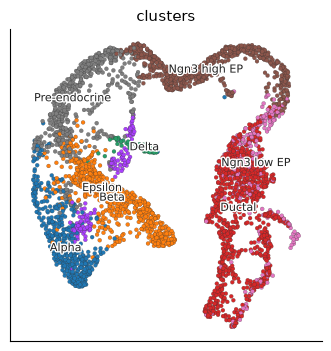

In [4]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by='clusters',
    legend_loc='on_data',
)

In [5]:
pseudotime = ds.run_pseudotime_scoring(
    source_sink_key='clusters',
    sources=['Ductal'],
    sinks=['Alpha', 'Beta', 'Delta'],
)

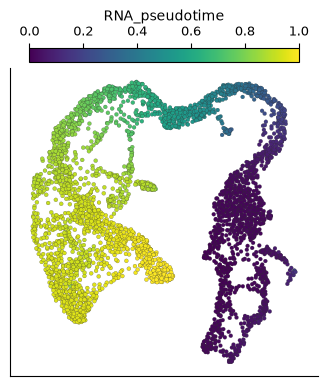

In [6]:
ds.plots.embedding(
    layout_key='RNA_UMAP',
    color_by=pseudotime.pseudotime_key,
)

In [7]:
markers = ds.run_pseudotime_marker_search(
    cell_key=pseudotime.validity_key,
    pseudotime_key=pseudotime.pseudotime_key,
)
(
    markers.table.loc[
        markers.table["p_value_adjusted"].notna(),
        ["feature_name", "r_value", "p_value_adjusted"],
    ]
    .assign(abs_r_value=lambda frame: frame["r_value"].abs())
    .sort_values("abs_r_value", ascending=False)
    .drop(columns="abs_r_value")
    .head(10)
)

Finding correlated features: 1 / 1 complete

,feature_name,r_value,p_value_adjusted
11497,Rpl13,-0.828517,0.0
10436,Rps19,-0.821364,0.0
8979,Spp1,-0.821112,0.0
7747,Rps8,-0.817098,0.0
9443,Rpl32,-0.793551,0.0
12367,Rps4x,-0.793366,0.0
177,Dbi,-0.788328,0.0
6533,Rpl12,-0.769530,0.0
4948,Rps2,-0.756031,0.0
4993,Rpl10a,-0.753413,0.0


In [8]:
checkpoint_genes = ["Spp1", "Cpe"]
checkpoint = (
    markers.table.set_index("feature_name")
    .loc[checkpoint_genes, ["r_value", "p_value_adjusted"]]
)
checkpoint

,r_value,p_value_adjusted
feature_name,,
Spp1,-0.821112,0.0
Cpe,0.739462,0.0


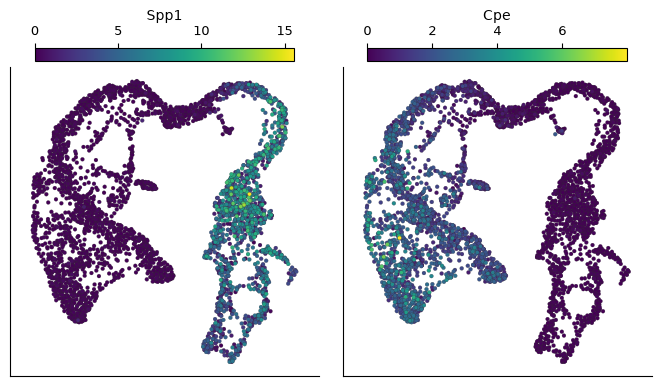

In [9]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=checkpoint_genes,
    n_columns=2,
    sort_values=True,
)